In [2]:
import time

start = time.time()

import torch

print("Loaded in:", time.time() - start)
print(torch.cuda.is_available())

Loaded in: 0.0
True


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [4]:
# STEP 2: Upload dataset
import pandas as pd

df = pd.read_csv("deceptive-opinion.csv")
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


In [5]:
# STEP 4: Data cleaning
df = df[["text", "deceptive"]]

df = df.rename(columns={
    "text": "review",
    "deceptive": "label"
})

df["label"] = df["label"].map({
    "truthful": 0,
    "deceptive": 1
})

df["review"] = df["review"].astype(str)
df["review"] = df["review"].str.strip()
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)

df = df.dropna()
df = df.drop_duplicates()

print(df.info())
print(df["label"].value_counts())

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1596 non-null   str  
 1   label   1596 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB
None
label
1    800
0    796
Name: count, dtype: int64


In [6]:
# STEP 5: Train / validation / test split
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"],
    df["label"],
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

In [7]:
# STEP 6: Tokenization
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

c:\ML_in_Cyber\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# STEP 7: Convert to PyTorch Dataset
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [9]:
# STEP 8: Compute class weights for class-balanced learning
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([1.0027, 0.9973])


In [10]:
# STEP 9: Load RoBERTa with tuned dropout
from transformers import RobertaConfig, RobertaForSequenceClassification

config = RobertaConfig.from_pretrained(
    "roberta-base",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.1
)

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    config=config
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4869.37it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# STEP 10: Evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [12]:
# STEP 11: Custom Trainer with weighted loss
from transformers import Trainer
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [13]:
# STEP 12: Training arguments with early stopping + optimized weight decay
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./proposed_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    report_to="none"
)

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3
)

In [14]:
# STEP 13: Train proposed model
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.550210,0.462177,0.824268,0.746835,0.983333,0.848921
2,0.249451,0.384368,0.874477,0.812500,0.975000,0.886364
3,0.169983,0.293942,0.899582,0.863636,0.950000,0.904762
4,0.111397,0.721429,0.874477,0.816901,0.966667,0.885496
5,0.058433,0.460796,0.928870,0.940171,0.916667,0.928270
6,0.015232,0.787182,0.887029,0.820690,0.991667,0.898113


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


TrainOutput(global_step=420, training_loss=0.19245108025414603, metrics={'train_runtime': 185.8137, 'train_samples_per_second': 60.114, 'train_steps_per_second': 3.767, 'total_flos': 881685146511360.0, 'train_loss': 0.19245108025414603, 'epoch': 6.0})

In [15]:
# STEP 14: Evaluate proposed model
results = trainer.evaluate(test_dataset)
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.015232,0.423829,6,0.866667,0.814286,0.950000,0.876923


{'eval_loss': 0.4238288998603821, 'eval_accuracy': 0.8666666666666667, 'eval_precision': 0.8142857142857143, 'eval_recall': 0.95, 'eval_f1': 0.8769230769230769}


In [16]:
# STEP 15: Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85       120
           1       0.81      0.95      0.88       120

    accuracy                           0.87       240
   macro avg       0.88      0.87      0.87       240
weighted avg       0.88      0.87      0.87       240

[[ 94  26]
 [  6 114]]


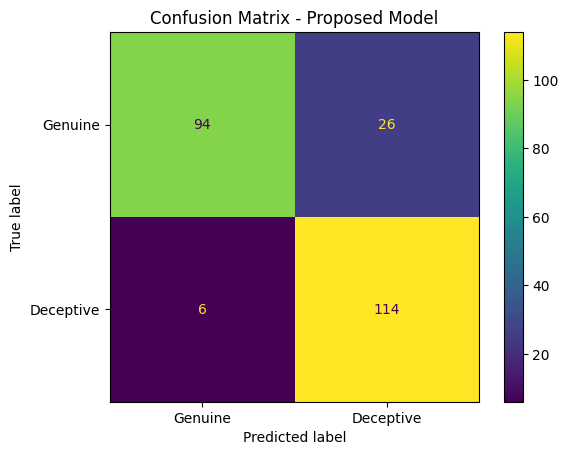

In [17]:
# STEP 16: Confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Genuine", "Deceptive"]
)

plt.title("Confusion Matrix - Proposed Model")
plt.show()

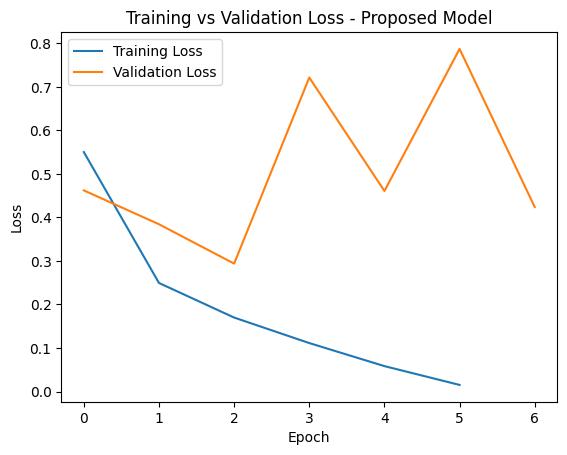

In [18]:
# STEP 17: Training vs validation loss graph
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - Proposed Model")
plt.legend()
plt.show()